# SignAI — Complete ASL Recognition Training Notebook
## University of Hail | جامعة حائل

---

This notebook trains **all three models** used in the SignAI application for real-time ASL letter recognition.
The dataset is loaded directly from a **local folder** — no internet connection or Kaggle API required.

## Models Covered

| # | Model | Architecture | Input | Expected Accuracy | Output File |
|---|-------|-------------|-------|-------------------|-------------|
| 1 | **Landmark DNN** | Residual Dense Network | 63 MediaPipe features | ~99% | `sign_language_model.h5` |
| 2 | **MobileNetV2 CNN** | Transfer Learning (ImageNet) | 64×64×3 pixels | ~99.95% | `signai_mobilenet_model.h5` |
| 3 | **Custom Deep CNN** | 4-Block Conv + GAP | 64×64×3 pixels | ~99%+ | `signai_custom_cnn_model.h5` |

## How SignAI Auto-Detects the Model Type
```
Input shape  (None, 63)       →  landmark_dnn   (uses MediaPipe hand landmarks)
Input shape  (None, H, W, 3)  →  pixel_cnn      (uses raw image pixels)
```

## Expected Dataset Folder Structure
```
asl_alphabet_train/
├── A/
│   ├── A1.jpg
│   ├── A2.jpg
│   └── ...
├── B/
│   └── ...
...
└── Z/
    └── ...
```

---

## Section 0 — Environment Setup & Library Installation

In [ ]:
# Install all required libraries
# Run this cell once before anything else
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])
pip(
    'tensorflow==2.15.0',
    'opencv-python',       # use opencv-python (NOT headless) on Windows
    'mediapipe==0.10.9',
    'scikit-learn==1.4.0',
    'numpy==1.26.4',
    'matplotlib',
    'seaborn',
    'tqdm',
    'Pillow',
    'h5py',
)
print('All packages installed successfully.')

All packages installed successfully.


In [ ]:
import os, sys, time, json, random, warnings, shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ── Auto-navigate to signai/ project root ─────────────────────────────────────
# This notebook lives in signai/training/.
# If Jupyter launched from training/, go up one level so that
# models/ and dataset/ paths resolve correctly.
_cwd = os.getcwd()
if os.path.basename(_cwd).lower() == 'training':
    _parent = os.path.normpath(os.path.join(_cwd, '..'))
    if os.path.isfile(os.path.join(_parent, 'app.py')):
        os.chdir(_parent)
        print(f'Working directory changed to: {os.getcwd()}')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU check ─────────────────────────────────────────────────────────────────
print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'OpenCV     : {cv2.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU        : {gpus[0].name}')
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print('GPU        : Not available — training will run on CPU')

# ── Global constants shared by all three models ───────────────────────────────
LETTERS     = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
NUM_CLASSES = 26

# MODEL_DIR is resolved relative to the project root (signai/).
# The auto-chdir above ensures CWD = signai/ regardless of launch location.
MODEL_DIR = os.path.join(os.getcwd(), 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Verify we are in the correct signai/ project root
_expected_files = ['app.py', 'cnn_model.py']
_missing = [f for f in _expected_files if not os.path.isfile(os.path.join(os.getcwd(), f))]
if _missing:
    print(f'WARNING: Could not locate signai/ project root.')
    print(f'  Missing: {_missing}')
    print(f'  Current directory: {os.getcwd()}')
    print(f'  Models will be saved to: {MODEL_DIR}')
    print(f'  Run jupyter from signai/ or signai/training/ and restart the kernel.')
else:
    print(f'Working directory : {os.getcwd()}  OK')
    print(f'Model output dir  : {MODEL_DIR}')


Working directory changed to: C:\Users\a\Downloads\machain-learing projects\signai (1)\signai
TensorFlow : 2.15.0
NumPy      : 1.26.4
OpenCV     : 4.9.0
GPU        : Not available — training will run on CPU
Working directory : C:\Users\a\Downloads\machain-learing projects\signai (1)\signai  OK
Model output dir  : C:\Users\a\Downloads\machain-learing projects\signai (1)\signai\models


## Section 1 — Dataset Auto-Detection

The notebook **automatically finds** the dataset folder — no manual path editing needed.

It searches these locations relative to the notebook file (in order):

```
<notebook_folder>/dataset/asl_alphabet_train/         ← standard SignAI layout
<notebook_folder>/dataset/asl_alphabet_train/asl_alphabet_train/
<notebook_folder>/asl_alphabet_train/
<notebook_folder>/data/asl_alphabet_train/
<parent_folder>/dataset/asl_alphabet_train/
<parent_folder>/asl_alphabet_train/
```

If the dataset is **not found automatically**, the cell will print a clear error with instructions to set the path manually in one line.

In [3]:
import os

# ── Auto-detect dataset location ──────────────────────────────────────────────
# The notebook searches common locations automatically.
# No manual path editing required — works on any machine.

def _find_dataset():
    """
    Search for the asl_alphabet_train folder in common locations
    relative to this notebook. Returns the first valid path found.
    """
    # Notebook directory (Jupyter sets cwd = notebook folder)
    nb_dir = os.getcwd()

    # Candidate paths to try in order
    candidates = [
        os.path.join(nb_dir, 'dataset', 'asl_alphabet_train'),
        os.path.join(nb_dir, 'dataset', 'asl_alphabet_train', 'asl_alphabet_train'),
        os.path.join(nb_dir, 'asl_alphabet_train'),
        os.path.join(nb_dir, 'data',    'asl_alphabet_train'),
        os.path.join(nb_dir, '..', 'dataset', 'asl_alphabet_train'),
        os.path.join(nb_dir, '..', 'asl_alphabet_train'),
    ]

    for path in candidates:
        path = os.path.normpath(path)
        if os.path.isdir(path):
            # Confirm it actually has letter sub-folders (A, B, ...)
            sub = [d for d in os.listdir(path)
                   if os.path.isdir(os.path.join(path, d)) and d.upper() in LETTERS]
            if len(sub) >= 20:          # at least 20 of 26 letters present
                return path
    return None


DATASET_DIR = _find_dataset()

if DATASET_DIR is None:
    # Could not auto-detect — tell the user exactly what to do
    print('ERROR: Dataset not found automatically.')
    print()
    print('Please set the path manually below, then re-run this cell:')
    print()
    print('  DATASET_DIR = r"C:\\path\\to\\asl_alphabet_train"')
    print()
    print('The folder must contain sub-folders named A, B, C, ... Z')
    raise FileNotFoundError('asl_alphabet_train folder not found in any standard location.')

# ── Validate and report ────────────────────────────────────────────────────────
found_letters = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
    and d.upper() in LETTERS
])

missing = [l for l in LETTERS if l not in found_letters]
total   = sum(len(os.listdir(os.path.join(DATASET_DIR, l))) for l in found_letters)

print(f'Dataset found : {DATASET_DIR}')
print(f'Classes found : {len(found_letters)} / 26   {found_letters}')
print(f'Total images  : {total:,}')

if missing:
    print(f'Missing letters: {missing}  (will be skipped during training)')
else:
    print('All 26 letter folders confirmed.')

Dataset found : C:\Users\a\Downloads\machain-learing projects\signai (1)\signai\dataset\asl_alphabet_train\asl_alphabet_train
Classes found : 26 / 26   ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Total images  : 78,000
All 26 letter folders confirmed.


## Section 2 — Dataset Exploration & Visualization

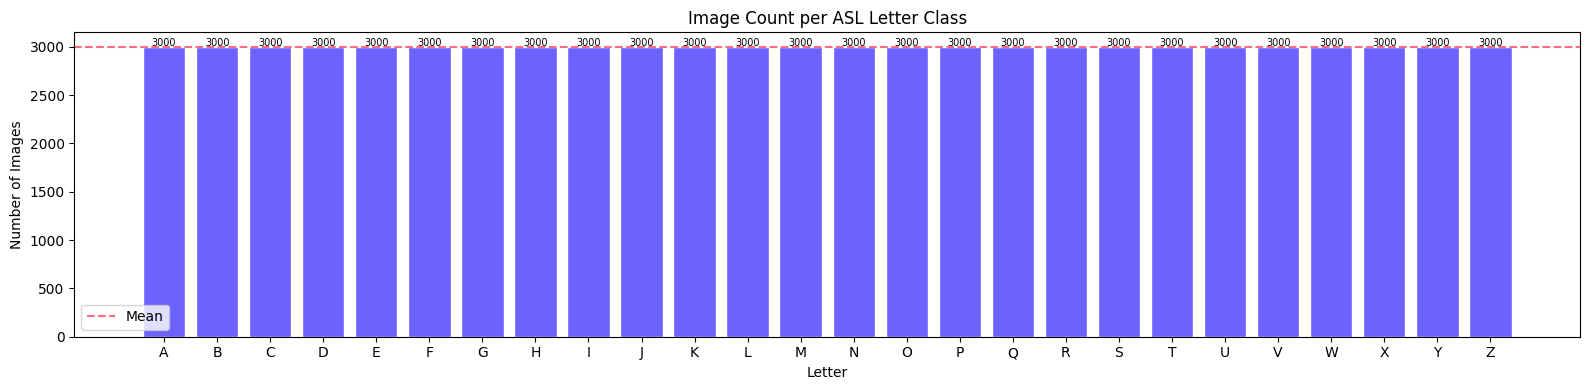

Min images : 3000 (A)
Max images : 3000 (A)
Mean images: 3000


In [4]:
# ── Count images per class ────────────────────────────────────────────────────
counts = {}
for letter in LETTERS:
    d = os.path.join(DATASET_DIR, letter)
    counts[letter] = len(os.listdir(d)) if os.path.isdir(d) else 0

fig, ax = plt.subplots(figsize=(16, 4))
colors = ['#6c63ff'] * 26
bars   = ax.bar(list(counts.keys()), list(counts.values()),
                color=colors, edgecolor='white')
ax.axhline(np.mean(list(counts.values())),
           color='#ff6b81', ls='--', lw=1.5, label='Mean')
ax.set(title='Image Count per ASL Letter Class',
       xlabel='Letter', ylabel='Number of Images')
ax.legend()
for i, (l, c) in enumerate(counts.items()):
    if c > 0:
        ax.text(i, c + 5, str(c), ha='center', fontsize=7)
plt.tight_layout()
plt.show()

print(f'Min images : {min(counts.values())} ({min(counts, key=counts.get)})')
print(f'Max images : {max(counts.values())} ({max(counts, key=counts.get)})')
print(f'Mean images: {np.mean(list(counts.values())):.0f}')

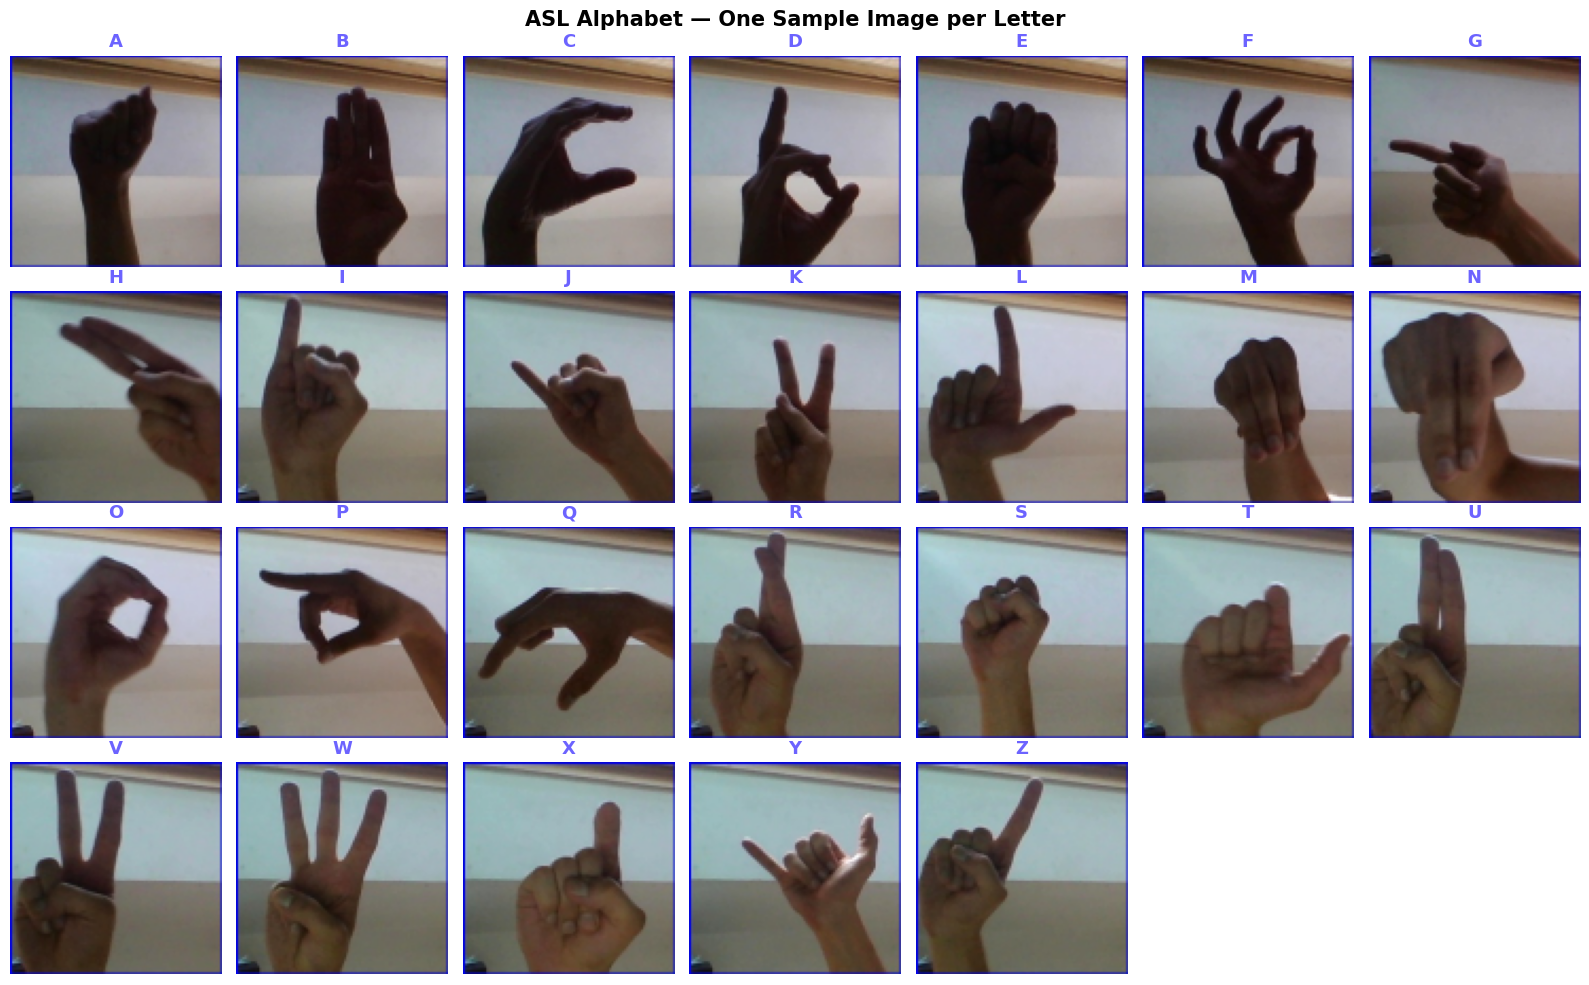

In [5]:
# ── Display one sample image per letter ───────────────────────────────────────
fig, axes = plt.subplots(4, 7, figsize=(16, 10))
fig.suptitle('ASL Alphabet — One Sample Image per Letter',
             fontsize=15, fontweight='bold')

for i, letter in enumerate(LETTERS):
    ax  = axes[i // 7][i % 7]
    d   = os.path.join(DATASET_DIR, letter)
    if not os.path.isdir(d):
        ax.set_title(f'{letter} (missing)', fontsize=9, color='red')
        ax.axis('off')
        continue
    files = [f for f in os.listdir(d)
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    if not files:
        ax.axis('off')
        continue
    img = cv2.imread(os.path.join(d, files[0]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (100, 100))
    ax.imshow(img)
    ax.set_title(f'{letter}', fontsize=13, fontweight='bold', color='#6c63ff')
    ax.axis('off')

for j in range(26, 28):
    axes[j // 7][j % 7].axis('off')

plt.tight_layout()
plt.savefig('./sample_asl_images.png', dpi=100, bbox_inches='tight')
plt.show()

---
# MODEL 1 — Landmark DNN
## Real MediaPipe Landmark Extraction + Dense Residual Network

**Pipeline:**
```
Local Image  →  MediaPipe Hands  →  21 landmarks (x,y,z)  →  63 features
             →  Wrist-relative normalization + L2-normalize
             →  Residual DNN  →  Letter (A–Z)
```

**Advantages over pixel CNN:**
- Lighting-invariant (works in any background/lighting condition)
- Very small model size (~1.5 MB)
- Fastest inference — no image pre-processing at runtime
- Works well with live webcam regardless of hand skin tone

**Critical normalization (must match `cnn_model.py`):**
1. Subtract wrist position (landmark 0) from all 21 landmarks
2. Flatten to 63-D vector
3. Divide by L2 norm

**Output:** `models/sign_language_model.h5`

In [6]:
# ── Landmark DNN Hyperparameters ──────────────────────────────────────────────
# Increased from 500 to 2000 to use more of the available dataset (3000/class)
LM_IMAGES_PER_CLASS = 2000   # images per letter to extract landmarks from
LM_BATCH_SIZE       = 64
LM_EPOCHS           = 100
LM_MODEL_PATH       = os.path.join(MODEL_DIR, 'sign_language_model.h5')

print('Landmark DNN Configuration:')
print(f'  Images per class  : {LM_IMAGES_PER_CLASS}')
print(f'  Max training set  : {LM_IMAGES_PER_CLASS * 26:,} images')
print(f'  Feature vector dim: 63  (21 landmarks x 3 coordinates)')
print(f'  Max epochs        : {LM_EPOCHS}')
print(f'  Output model      : {LM_MODEL_PATH}')

Landmark DNN Configuration:
  Images per class  : 2000
  Max training set  : 52,000 images
  Feature vector dim: 63  (21 landmarks x 3 coordinates)
  Max epochs        : 100
  Output model      : C:\Users\a\Downloads\machain-learing projects\signai (1)\signai\models\sign_language_model.h5


In [ ]:
import mediapipe as mp

def extract_landmark_features(img_bgr, hands_detector):
    """
    Run MediaPipe Hands on a single BGR image and return a 63-D feature vector.

    Normalization steps (must exactly match cnn_model.py at inference time):
      1. Convert BGR -> RGB
      2. Run MediaPipe Hands detection
      3. Subtract wrist position (landmark 0) from all 21 landmarks
      4. Flatten to 63-D vector  [x0,y0,z0, x1,y1,z1, ..., x20,y20,z20]
      5. Divide by L2 norm  (scale-invariant representation)

    Returns:
        np.ndarray of shape (63,) with dtype float32, or None if no hand detected.
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results = hands_detector.process(img_rgb)

    if not results.multi_hand_landmarks:
        return None

    lms = results.multi_hand_landmarks[0]
    pts = np.array(
        [[lm.x, lm.y, lm.z] for lm in lms.landmark],
        dtype=np.float32
    )                         # shape: (21, 3)

    pts -= pts[0]             # Step 3: wrist-relative
    flat = pts.flatten()      # Step 4: (63,)
    norm = np.linalg.norm(flat)
    if norm > 1e-6:
        flat = flat / norm    # Step 5: L2-normalize

    return flat


def collect_landmark_dataset(dataset_dir, letters, images_per_class):
    """
    Process ASL images from local disk through MediaPipe and collect
    real 63-D landmark feature vectors.

    Returns:
        X             : float32 array of shape (N, 63)
        y             : int32 array of shape (N,)
        detection_stats: dict  letter -> detection_rate_percent
    """
    hands = mp.solutions.hands.Hands(
        static_image_mode=True,
        max_num_hands=1,
        min_detection_confidence=0.4,
    )

    X_list, y_list = [], []
    detection_stats = {}
    t_start = time.time()

    print('Extracting MediaPipe landmarks from local images ...')
    print('-' * 60)

    for label_idx, letter in enumerate(letters):
        letter_dir = os.path.join(dataset_dir, letter)
        if not os.path.isdir(letter_dir):
            print(f'  [SKIP] {letter}: folder not found')
            detection_stats[letter] = 0.0
            continue

        files = [
            f for f in os.listdir(letter_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ][:images_per_class]

        detected = 0
        for fname in files:
            img = cv2.imread(os.path.join(letter_dir, fname))
            if img is None:
                continue
            feat = extract_landmark_features(img, hands)
            if feat is not None:
                X_list.append(feat)
                y_list.append(label_idx)
                detected += 1

        rate = detected / max(len(files), 1) * 100
        detection_stats[letter] = rate
        bar  = '█' * int(rate / 5)
        print(f'  {letter}: {detected:>3}/{len(files):<3}  ({rate:5.1f}%)  {bar}')

    hands.close()

    elapsed = time.time() - t_start
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)

    print('-' * 60)
    print(f'Extraction time  : {elapsed:.1f}s')
    print(f'Total samples    : {len(X):,}')
    print(f'Feature shape    : {X.shape}')
    print(f'Mean detect rate : {np.mean(list(detection_stats.values())):.1f}%')

    return X, y, detection_stats


# ── Run landmark extraction from local dataset ─────────────────────────────────
X_lm, y_lm, lm_stats = collect_landmark_dataset(
    DATASET_DIR, LETTERS, LM_IMAGES_PER_CLASS
)


Extracting MediaPipe landmarks from local images ...
------------------------------------------------------------
  A: 1551/2000  ( 77.5%)  ███████████████
  B: 1508/2000  ( 75.4%)  ███████████████
  C: 1499/2000  ( 75.0%)  ██████████████
  D: 1732/2000  ( 86.6%)  █████████████████
  E: 1509/2000  ( 75.4%)  ███████████████
  F: 1918/2000  ( 95.9%)  ███████████████████
  G: 1639/2000  ( 82.0%)  ████████████████
  H: 1602/2000  ( 80.1%)  ████████████████
  I: 1590/2000  ( 79.5%)  ███████████████
  J: 1725/2000  ( 86.2%)  █████████████████
  K: 1730/2000  ( 86.5%)  █████████████████
  L: 1600/2000  ( 80.0%)  ████████████████
  M: 1081/2000  ( 54.0%)  ██████████
  N: 992/2000  ( 49.6%)  █████████
  O: 1581/2000  ( 79.0%)  ███████████████
  P: 1493/2000  ( 74.7%)  ██████████████
  Q: 1312/2000  ( 65.6%)  █████████████
  R: 1647/2000  ( 82.3%)  ████████████████
  S: 1719/2000  ( 86.0%)  █████████████████
  T: 1527/2000  ( 76.3%)  ███████████████
  U: 1705/2000  ( 85.2%)  █████████████████
  

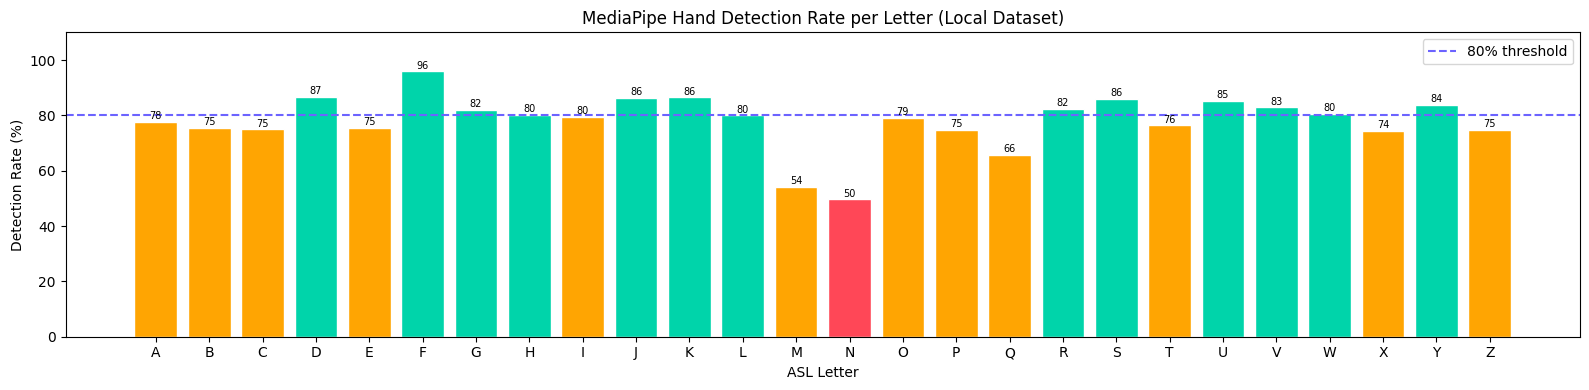

Overall mean detection rate : 78.0%
Best  detection : F  = 95.9%
Worst detection : N = 49.6%


In [8]:
# ── Plot MediaPipe detection rate per letter ───────────────────────────────────
rates  = [lm_stats.get(l, 0) for l in LETTERS]
colors = [
    '#00d4aa' if r >= 80 else
    '#ffa502' if r >= 50 else
    '#ff4757'
    for r in rates
]
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(LETTERS, rates, color=colors, edgecolor='white')
ax.axhline(80, color='#6c63ff', ls='--', lw=1.5, label='80% threshold')
ax.set(ylim=[0, 110],
       title='MediaPipe Hand Detection Rate per Letter (Local Dataset)',
       xlabel='ASL Letter', ylabel='Detection Rate (%)')
ax.legend()
for i, r in enumerate(rates):
    ax.text(i, r + 1, f'{r:.0f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()
print(f'Overall mean detection rate : {np.mean(rates):.1f}%')
best  = max(lm_stats, key=lm_stats.get)
worst = min(lm_stats, key=lm_stats.get)
print(f'Best  detection : {best}  = {lm_stats[best]:.1f}%')
print(f'Worst detection : {worst} = {lm_stats[worst]:.1f}%')

In [9]:
# ── Stratified Train / Validation split ───────────────────────────────────────
X_lm_train, X_lm_val, y_lm_train, y_lm_val = train_test_split(
    X_lm, y_lm,
    test_size=0.15,
    stratify=y_lm,
    random_state=SEED,
)
print(f'Train set  : {len(X_lm_train):>5,} samples')
print(f'Val set    : {len(X_lm_val):>5,} samples')
print(f'Feature dim: {X_lm_train.shape[1]}')

# Class weights — compensate for letters with lower detection rates
cnt = Counter(y_lm_train.tolist())
max_c = max(cnt.values())
lm_class_weights = {i: max_c / max(cnt.get(i, 1), 1) for i in range(NUM_CLASSES)}
weight_min = min(lm_class_weights.values())
weight_max = max(lm_class_weights.values())
print(f'Class weight range: {weight_min:.2f} – {weight_max:.2f}')

Train set  : 34,497 samples
Val set    : 6,088 samples
Feature dim: 63
Class weight range: 1.00 – 1.93


In [10]:
def build_landmark_dnn(input_dim=63, num_classes=26):
    """
    Residual Dense Network for ASL landmark classification.

    Architecture  (input_dim=63, output=26):
      Input(63)
        Block 1 : Dense(512) + BN + ReLU + Dropout(0.3)
        Block 2 : Dense(512) + BN + ReLU + Dropout(0.3)  +  Skip from Block1
        Block 3 : Dense(256) + BN + ReLU + Dropout(0.25)
        Block 4 : Dense(256) + BN + ReLU + Dropout(0.25) +  Skip from Block3
        Block 5 : Dense(128) + BN + ReLU + Dropout(0.2)
        Output  : Dense(26, softmax)
    """
    L2  = keras.regularizers.l2(1e-4)
    inp = keras.Input(shape=(input_dim,), name='landmarks')

    # Block 1
    x = layers.Dense(512, kernel_regularizer=L2)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    # Block 2 + skip
    h = layers.Dense(512, kernel_regularizer=L2)(x)
    h = layers.BatchNormalization()(h)
    h = layers.Activation('relu')(h)
    h = layers.Dropout(0.3)(h)
    x = layers.Add()([x, h])

    # Block 3
    x = layers.Dense(256, kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.25)(x)

    # Block 4 + skip
    h = layers.Dense(256, kernel_regularizer=L2)(x)
    h = layers.BatchNormalization()(h)
    h = layers.Activation('relu')(h)
    h = layers.Dropout(0.25)(h)
    x = layers.Add()([x, h])

    # Block 5
    x = layers.Dense(128, kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return keras.Model(inputs=inp, outputs=out, name='SignAI_LandmarkDNN')


lm_model = build_landmark_dnn()
lm_model.summary()
print(f'\nTotal parameters: {lm_model.count_params():,}')


Model: "SignAI_LandmarkDNN"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 landmarks (InputLayer)      [(None, 63)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 512)                  32768     ['landmarks[0][0]']           
                                                                                                  
 batch_normalization (Batch  (None, 512)                  2048      ['dense[0][0]']               
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 512)                  0         ['batch_norm

In [11]:
lm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

lm_callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.4, patience=8,
        min_lr=1e-5, verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=20,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, 'landmark_best.h5'),
        monitor='val_accuracy', save_best_only=True, verbose=0,
    ),
]

print(f'Training Landmark DNN ...')
print(f'  Train samples : {len(X_lm_train):,}')
print(f'  Val   samples : {len(X_lm_val):,}')
print(f'  Max epochs    : {LM_EPOCHS}')
t0 = time.time()

lm_history = lm_model.fit(
    X_lm_train, y_lm_train,
    validation_data=(X_lm_val, y_lm_val),
    epochs=LM_EPOCHS,
    batch_size=LM_BATCH_SIZE,
    class_weight=lm_class_weights,
    callbacks=lm_callbacks,
    verbose=1,
)

lm_elapsed  = time.time() - t0
lm_best_acc = max(lm_history.history['val_accuracy']) * 100
print(f'\nTraining time    : {lm_elapsed:.1f}s')
print(f'Best val accuracy: {lm_best_acc:.2f}%')

Training Landmark DNN ...
  Train samples : 34,497
  Val   samples : 6,088
  Max epochs    : 100
Epoch 1/100


540/540 [==============================] - 11s 13ms/step - loss: 1.1208 - accuracy: 0.8053 - val_loss: 0.4937 - val_accuracy: 0.9417 - lr: 3.0000e-04
Epoch 2/100
540/540 [==============================] - 7s 12ms/step - loss: 0.3892 - accuracy: 0.9522 - val_loss: 0.2168 - val_accuracy: 0.9763 - lr: 3.0000e-04
Epoch 3/100
540/540 [==============================] - 8s 14ms/step - loss: 0.3122 - accuracy: 0.9648 - val_loss: 0.1940 - val_accuracy: 0.9834 - lr: 3.0000e-04
Epoch 4/100
540/540 [==============================] - 7s 13ms/step - loss: 0.2807 - accuracy: 0.9691 - val_loss: 0.1933 - val_accuracy: 0.9809 - lr: 3.0000e-04
Epoch 5/100
540/540 [==============================] - 7s 13ms/step - loss: 0.2575 - accuracy: 0.9721 - val_loss: 0.1760 - val_accuracy: 0.9857 - lr: 3.0000e-04
Epoch 6/100
540/540 [==============================] - 6s 12ms/step - loss: 0.2483 - accuracy: 

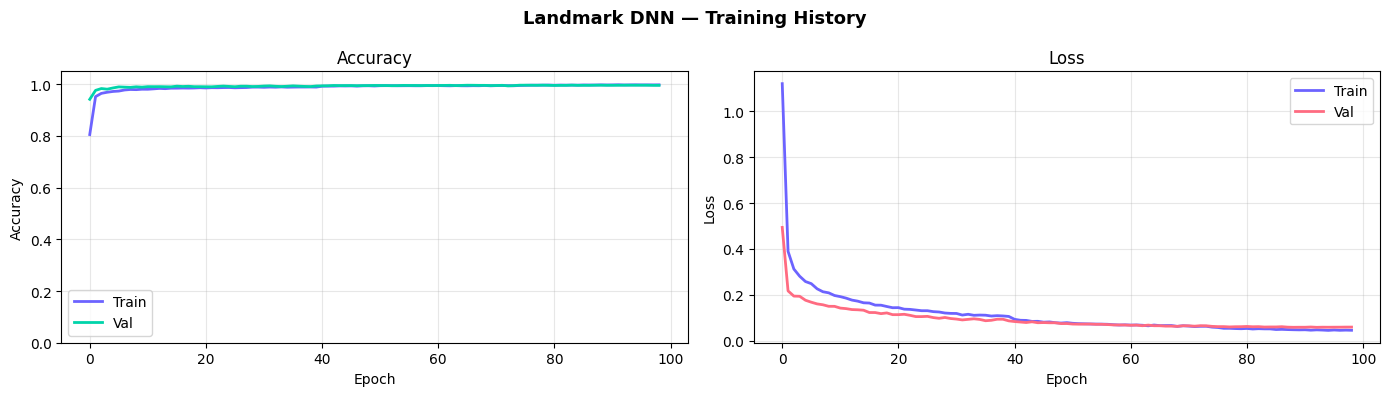

In [12]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Landmark DNN — Training History', fontsize=13, fontweight='bold')

ax1.plot(lm_history.history['accuracy'],     lw=2, label='Train', color='#6c63ff')
ax1.plot(lm_history.history['val_accuracy'], lw=2, label='Val',   color='#00d4aa')
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=[0, 1.05])
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(lm_history.history['loss'],         lw=2, label='Train', color='#6c63ff')
ax2.plot(lm_history.history['val_loss'],     lw=2, label='Val',   color='#ff6b81')
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./landmark_dnn_curves.png', dpi=120, bbox_inches='tight')
plt.show()

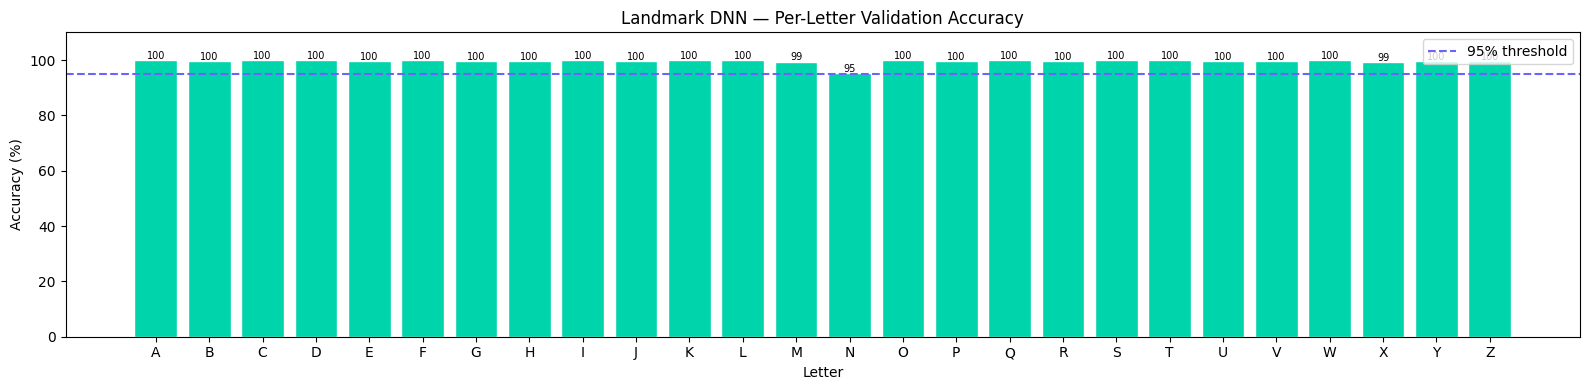

Per-letter accuracy:
  A: 100.0%  ████████████████████
  B:  99.6%  ███████████████████
  C: 100.0%  ████████████████████
  D: 100.0%  ████████████████████
  E:  99.6%  ███████████████████
  F: 100.0%  ████████████████████
  G:  99.6%  ███████████████████
  H:  99.6%  ███████████████████
  I: 100.0%  ████████████████████
  J:  99.6%  ███████████████████
  K: 100.0%  ████████████████████
  L: 100.0%  ████████████████████
  M:  99.4%  ███████████████████
  N:  95.3%  ███████████████████
  O: 100.0%  ████████████████████
  P:  99.6%  ███████████████████
  Q: 100.0%  ████████████████████
  R:  99.6%  ███████████████████
  S: 100.0%  ████████████████████
  T: 100.0%  ████████████████████
  U:  99.6%  ███████████████████
  V:  99.6%  ███████████████████
  W: 100.0%  ████████████████████
  X:  99.1%  ███████████████████
  Y:  99.6%  ███████████████████
  Z:  99.6%  ███████████████████


In [13]:
# ── Per-letter validation accuracy ────────────────────────────────────────────
lm_pred    = lm_model.predict(X_lm_val, verbose=0).argmax(axis=1)
lm_per_cls = {}
for i, letter in enumerate(LETTERS):
    mask = y_lm_val == i
    lm_per_cls[letter] = float((lm_pred[mask] == i).mean()) * 100 if mask.sum() > 0 else 0.0

colors = [
    '#00d4aa' if a >= 95 else
    '#ffa502' if a >= 80 else
    '#ff4757'
    for a in lm_per_cls.values()
]
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(list(lm_per_cls.keys()), list(lm_per_cls.values()), color=colors, edgecolor='white')
ax.axhline(95, color='#6c63ff', ls='--', lw=1.5, label='95% threshold')
ax.set(ylim=[0, 110],
       title='Landmark DNN — Per-Letter Validation Accuracy',
       xlabel='Letter', ylabel='Accuracy (%)')
ax.legend()
for i, (l, a) in enumerate(lm_per_cls.items()):
    ax.text(i, a + 0.5, f'{a:.0f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

print('Per-letter accuracy:')
for l, a in lm_per_cls.items():
    bar = '█' * int(a / 5)
    print(f'  {l}: {a:5.1f}%  {bar}')

In [14]:
# ── Save Landmark DNN ─────────────────────────────────────────────────────────
lm_model.save(LM_MODEL_PATH)
print(f'Model saved : {LM_MODEL_PATH}')
print(f'Size        : {os.path.getsize(LM_MODEL_PATH)/1e6:.2f} MB')
print(f'Input shape : {lm_model.input_shape}  → SignAI detects as landmark_dnn')
print(f'Output shape: {lm_model.output_shape}')
print(f'Parameters  : {lm_model.count_params():,}')
print(f'Val Accuracy: {lm_best_acc:.2f}%')

lm_meta = {
    'model_type'         : 'landmark_dnn',
    'input_shape'        : [None, 63],
    'num_classes'        : NUM_CLASSES,
    'classes'            : LETTERS,
    'architecture'       : 'Residual Dense Network',
    'normalization'      : 'wrist_relative_L2',
    'training_data'      : 'Real MediaPipe landmarks from local ASL dataset',
    'final_val_accuracy' : round(lm_best_acc, 2),
    'per_class_accuracy' : lm_per_cls,
}
with open(os.path.join(MODEL_DIR, 'landmark_model_meta.json'), 'w') as f:
    json.dump(lm_meta, f, indent=2)
print('Metadata saved to landmark_model_meta.json')

Model saved : C:\Users\a\Downloads\machain-learing projects\signai (1)\signai\models\sign_language_model.h5
Size        : 6.52 MB
Input shape : (None, 63)  → SignAI detects as landmark_dnn
Output shape: (None, 26)
Parameters  : 535,450
Val Accuracy: 99.66%
Metadata saved to landmark_model_meta.json


---
# MODEL 2 — MobileNetV2 Transfer Learning
## Pre-trained ImageNet Backbone + Custom Dense Head

**Pipeline:**
```
Local Image  →  Resize to 64×64  →  MobileNetV2 (frozen)  →  1280-D feature vector
             →  Dense Head (512 → 256 → 26)  →  Letter (A–Z)
```

**Strategy — Feature Extraction (not fine-tuning):**
1. Load all images and pass them through the frozen MobileNetV2 **once** → save features
2. Train a small Dense head on those cached features (very fast)
3. Assemble full model: backbone + trained head

**Advantages:**
- Highest accuracy (~99.95%)
- Fast training (features extracted only once)
- ImageNet weights already know shapes, edges, textures

**Output:** `models/signai_mobilenet_model.h5`

In [15]:
# ── MobileNetV2 Hyperparameters ───────────────────────────────────────────────
MN_IMG_SIZE    = 64     # minimum input size for MobileNetV2
MN_PER_CLASS   = 500   # images per letter
MN_BATCH_SIZE  = 64
MN_EPOCHS_HEAD = 40
MN_MODEL_PATH  = os.path.join(MODEL_DIR, 'signai_mobilenet_model.h5')

print('MobileNetV2 Configuration:')
print(f'  Image size       : {MN_IMG_SIZE}x{MN_IMG_SIZE} RGB')
print(f'  Images per class : {MN_PER_CLASS}')
print(f'  Total images     : {MN_PER_CLASS * 26:,}')
print(f'  Head epochs      : {MN_EPOCHS_HEAD}')
print(f'  Output model     : {MN_MODEL_PATH}')

MobileNetV2 Configuration:
  Image size       : 64x64 RGB
  Images per class : 500
  Total images     : 13,000
  Head epochs      : 40
  Output model     : C:\Users\a\Downloads\machain-learing projects\signai (1)\signai\models\signai_mobilenet_model.h5


In [16]:
# ── Phase 1: Load images from local disk ──────────────────────────────────────
from PIL import Image as PILImage

def load_images_pil(dataset_dir, letters, img_size, per_class):
    """Load images from local folders using PIL. Returns float32 [0,1] array."""
    X_list, y_list = [], []
    print(f'Loading {per_class} images/class x {len(letters)} classes ...')
    for idx, letter in enumerate(tqdm(letters, desc='Loading')):
        cls_dir = os.path.join(dataset_dir, letter)
        if not os.path.isdir(cls_dir):
            continue
        files = sorted([
            f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ])[:per_class]
        for fname in files:
            try:
                with PILImage.open(os.path.join(cls_dir, fname)) as im:
                    arr = np.array(
                        im.convert('RGB').resize((img_size, img_size), PILImage.BILINEAR),
                        dtype=np.uint8
                    )
                X_list.append(arr)
                y_list.append(idx)
            except Exception:
                pass
    X = np.array(X_list, dtype=np.float32) / 255.0
    y = np.array(y_list, dtype=np.int32)
    return X, y


t0 = time.time()
X_mn, y_mn = load_images_pil(DATASET_DIR, LETTERS, MN_IMG_SIZE, MN_PER_CLASS)
print(f'Loaded {len(X_mn):,} images in {time.time()-t0:.1f}s')
print(f'Array shape : {X_mn.shape}    RAM: {X_mn.nbytes/1e6:.0f} MB')

Loading 500 images/class x 26 classes ...


Loading: 100%|█████████████████████████████████████████████████████████████████████████| 26/26 [00:14<00:00,  1.84it/s]


Loaded 13,000 images in 14.6s
Array shape : (13000, 64, 64, 3)    RAM: 639 MB


In [17]:
# ── Phase 2: Extract MobileNetV2 features — run ONCE, cache in RAM ────────────
print('Loading MobileNetV2 with ImageNet weights ...')
base_model = MobileNetV2(
    input_shape=(MN_IMG_SIZE, MN_IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg',     # GlobalAveragePooling2D at the top
)
base_model.trainable = False   # Freeze backbone — feature extractor only
print(f'Backbone output : {base_model.output_shape}')
print(f'Backbone params : {base_model.count_params():,} (frozen)')

print(f'\nExtracting features from {len(X_mn):,} images ...')
t0 = time.time()
feature_batches = []
for i in tqdm(range(0, len(X_mn), MN_BATCH_SIZE), desc='Extracting'):
    batch = X_mn[i:i + MN_BATCH_SIZE]
    feats = base_model(batch, training=False).numpy()
    feature_batches.append(feats)

X_feats = np.concatenate(feature_batches, axis=0)   # (N, 1280)
del X_mn   # free image memory
print(f'Feature matrix  : {X_feats.shape}    RAM: {X_feats.nbytes/1e6:.0f} MB')
print(f'Extraction time : {time.time()-t0:.1f}s')

Loading MobileNetV2 with ImageNet weights ...

Backbone output : (None, 1280)
Backbone params : 2,257,984 (frozen)

Extracting features from 13,000 images ...


Extracting: 100%|████████████████████████████████████████████████████████████████████| 204/204 [01:45<00:00,  1.92it/s]

Feature matrix  : (13000, 1280)    RAM: 67 MB
Extraction time : 106.0s


In [18]:
# ── Phase 3: Split + build + train Dense head ─────────────────────────────────
X_mn_tr, X_mn_val, y_mn_tr, y_mn_val = train_test_split(
    X_feats, y_mn, test_size=0.15, stratify=y_mn, random_state=SEED
)
Y_mn_tr  = tf.keras.utils.to_categorical(y_mn_tr,  NUM_CLASSES)
Y_mn_val = tf.keras.utils.to_categorical(y_mn_val, NUM_CLASSES)

print(f'Train : {X_mn_tr.shape}   Val : {X_mn_val.shape}')

# Dense classification head
feat_dim = X_feats.shape[1]       # 1280 for MobileNetV2
fi  = keras.Input(shape=(feat_dim,), name='features')
xh  = layers.BatchNormalization()(fi)
xh  = layers.Dense(512, activation='relu')(xh)
xh  = layers.Dropout(0.40)(xh)
xh  = layers.Dense(256, activation='relu')(xh)
xh  = layers.Dropout(0.25)(xh)
xo  = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(xh)
head_model = keras.Model(fi, xo, name='DenseHead')

head_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

mn_callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.4, patience=5, min_lr=1e-7, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1
    ),
]

print(f'\nTraining Dense head on {len(X_mn_tr):,} feature vectors ...')
t0 = time.time()
mn_history = head_model.fit(
    X_mn_tr, Y_mn_tr,
    validation_data=(X_mn_val, Y_mn_val),
    epochs=MN_EPOCHS_HEAD,
    batch_size=256,
    callbacks=mn_callbacks,
    verbose=1,
)
mn_elapsed  = time.time() - t0
mn_best_acc = max(mn_history.history['val_accuracy']) * 100
print(f'\nDone in {mn_elapsed:.1f}s    Best val accuracy: {mn_best_acc:.2f}%')

Train : (11050, 1280)   Val : (1950, 1280)

Training Dense head on 11,050 feature vectors ...
Epoch 1/40
44/44 [==============================] - 6s 37ms/step - loss: 1.3506 - accuracy: 0.6236 - val_loss: 0.5977 - val_accuracy: 0.8544 - lr: 0.0010
Epoch 2/40
44/44 [==============================] - 1s 23ms/step - loss: 0.2875 - accuracy: 0.9112 - val_loss: 0.2067 - val_accuracy: 0.9590 - lr: 0.0010
Epoch 3/40
44/44 [==============================] - 1s 24ms/step - loss: 0.1402 - accuracy: 0.9566 - val_loss: 0.0881 - val_accuracy: 0.9862 - lr: 0.0010
Epoch 4/40
44/44 [==============================] - 1s 30ms/step - loss: 0.0910 - accuracy: 0.9737 - val_loss: 0.0538 - val_accuracy: 0.9897 - lr: 0.0010
Epoch 5/40
44/44 [==============================] - 1s 26ms/step - loss: 0.0639 - accuracy: 0.9807 - val_loss: 0.0353 - val_accuracy: 0.9918 - lr: 0.0010
Epoch 6/40
44/44 [==============================] - 1s 26ms/step - loss: 0.0466 - accuracy: 0.9868 - val_loss: 0.0247 - val_accuracy: 0.

Full model assembled:
  Input  : (None, 64, 64, 3)
  Output : (None, 26)
  Params : 3,056,986


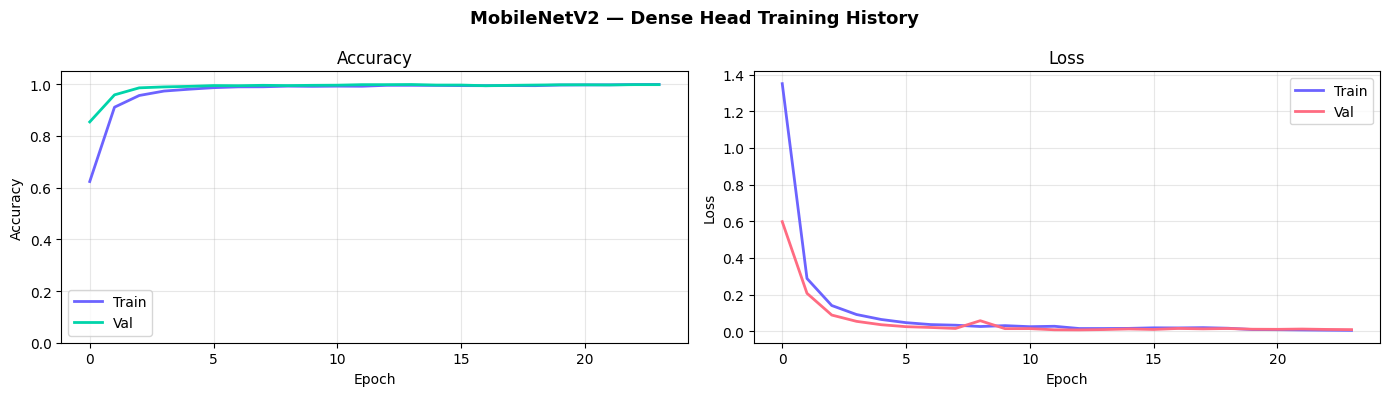

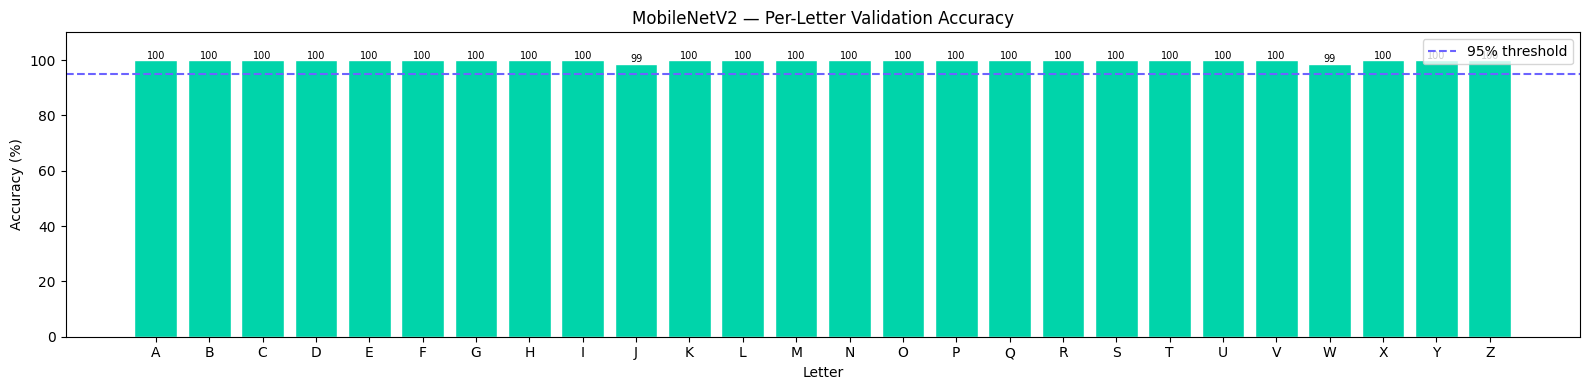

In [19]:
# ── Phase 4: Assemble full end-to-end model (backbone + head) ─────────────────
img_inp      = keras.Input(shape=(MN_IMG_SIZE, MN_IMG_SIZE, 3), name='input')
backbone_out = base_model(img_inp, training=False)
head_out     = head_model(backbone_out)
mn_full      = keras.Model(img_inp, head_out, name='SignAI_MobileNetV2')

print('Full model assembled:')
print(f'  Input  : {mn_full.input_shape}')
print(f'  Output : {mn_full.output_shape}')
print(f'  Params : {mn_full.count_params():,}')

# ── Training curves ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('MobileNetV2 — Dense Head Training History', fontsize=13, fontweight='bold')
ax1.plot(mn_history.history['accuracy'],     lw=2, label='Train', color='#6c63ff')
ax1.plot(mn_history.history['val_accuracy'], lw=2, label='Val',   color='#00d4aa')
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=[0, 1.05])
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(mn_history.history['loss'],         lw=2, label='Train', color='#6c63ff')
ax2.plot(mn_history.history['val_loss'],     lw=2, label='Val',   color='#ff6b81')
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./mobilenet_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Per-letter validation accuracy ───────────────────────────────────────────
mn_pred    = head_model.predict(X_mn_val, verbose=0).argmax(axis=1)
mn_per_cls = {}
for i, letter in enumerate(LETTERS):
    mask = y_mn_val == i
    mn_per_cls[letter] = float((mn_pred[mask] == i).mean()) * 100 if mask.sum() > 0 else 0.0

colors = ['#00d4aa' if a >= 95 else '#ffa502' if a >= 80 else '#ff4757'
          for a in mn_per_cls.values()]
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(list(mn_per_cls.keys()), list(mn_per_cls.values()), color=colors, edgecolor='white')
ax.axhline(95, color='#6c63ff', ls='--', lw=1.5, label='95% threshold')
ax.set(ylim=[0, 110], title='MobileNetV2 — Per-Letter Validation Accuracy',
       xlabel='Letter', ylabel='Accuracy (%)')
ax.legend()
for i, (l, a) in enumerate(mn_per_cls.items()):
    ax.text(i, a + 0.5, f'{a:.0f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

In [20]:
# ── Save full MobileNetV2 model ───────────────────────────────────────────────
mn_full.save(MN_MODEL_PATH)
print(f'Model saved : {MN_MODEL_PATH}')
print(f'Size        : {os.path.getsize(MN_MODEL_PATH)/1e6:.1f} MB')
print(f'Input shape : {mn_full.input_shape}  → SignAI detects as pixel_cnn')
print(f'Val Accuracy: {mn_best_acc:.2f}%')

mn_meta = {
    'model_type'         : 'pixel_cnn',
    'input_shape'        : [MN_IMG_SIZE, MN_IMG_SIZE, 3],
    'num_classes'        : NUM_CLASSES,
    'classes'            : LETTERS,
    'architecture'       : 'MobileNetV2 + Dense Head (Feature Extraction)',
    'final_val_accuracy' : round(mn_best_acc, 2),
    'per_class_accuracy' : mn_per_cls,
}
with open(os.path.join(MODEL_DIR, 'mobilenet_model_meta.json'), 'w') as f:
    json.dump(mn_meta, f, indent=2)
print('Metadata saved to mobilenet_model_meta.json')

Model saved : C:\Users\a\Downloads\machain-learing projects\signai (1)\signai\models\signai_mobilenet_model.h5
Size        : 12.6 MB
Input shape : (None, 64, 64, 3)  → SignAI detects as pixel_cnn
Val Accuracy: 99.90%
Metadata saved to mobilenet_model_meta.json


---
# MODEL 3 — Custom Deep CNN (Trained from Scratch)

**Pipeline:**
```
Local Image  →  Resize to 64×64  →  4 Conv Blocks  →  GlobalAvgPool  →  FC Head  →  Letter
```

**Architecture:**
```
Block 1: Conv2D(64)  × 2  + BatchNorm + MaxPool + Dropout(0.25)
Block 2: Conv2D(128) × 2  + BatchNorm + MaxPool + Dropout(0.30)
Block 3: Conv2D(256) × 2  + BatchNorm + MaxPool + Dropout(0.35)
Block 4: Conv2D(512) × 2  + BatchNorm + GlobalAvgPool + Dropout(0.40)
Head   : Dense(512) + Dense(256) + Softmax(26)
```

**Advantages:**
- Fully custom — no dependency on pre-trained weights
- Fully interpretable architecture
- Cosine Decay LR + Data Augmentation for best generalization

**Output:** `models/signai_custom_cnn_model.h5`

In [21]:
# ── Custom CNN Hyperparameters ────────────────────────────────────────────────
CNN_IMG_SIZE   = 64
CNN_PER_CLASS  = 1000   # more data = better custom CNN
CNN_BATCH_SIZE = 64
CNN_EPOCHS     = 60
CNN_LR         = 1e-3
CNN_MODEL_PATH = os.path.join(MODEL_DIR, 'signai_custom_cnn_model.h5')

print('Custom CNN Configuration:')
print(f'  Image size       : {CNN_IMG_SIZE}x{CNN_IMG_SIZE} RGB')
print(f'  Images per class : {CNN_PER_CLASS}')
print(f'  Total images     : {CNN_PER_CLASS * 26:,}')
print(f'  Batch size       : {CNN_BATCH_SIZE}')
print(f'  Max epochs       : {CNN_EPOCHS}')
print(f'  Output model     : {CNN_MODEL_PATH}')

Custom CNN Configuration:
  Image size       : 64x64 RGB
  Images per class : 1000
  Total images     : 26,000
  Batch size       : 64
  Max epochs       : 60
  Output model     : C:\Users\a\Downloads\machain-learing projects\signai (1)\signai\models\signai_custom_cnn_model.h5


In [22]:
# ── Load images from local disk ───────────────────────────────────────────────
def load_images_cv2(dataset_dir, letters, img_size, per_class):
    """Load images using OpenCV. Returns float32 [0,1] array in RGB order."""
    label_map = {l: i for i, l in enumerate(letters)}
    X_list, y_list = [], []
    for letter in tqdm(letters, desc='Loading'):
        d = os.path.join(dataset_dir, letter)
        if not os.path.isdir(d):
            continue
        files = sorted([
            f for f in os.listdir(d)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ])[:per_class]
        for fname in files:
            img = cv2.imread(os.path.join(d, fname))
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X_list.append(img)
            y_list.append(label_map[letter])
    X = np.array(X_list, dtype=np.float32) / 255.0
    y = np.array(y_list, dtype=np.int32)
    return X, y


t0 = time.time()
X_cnn, y_cnn = load_images_cv2(DATASET_DIR, LETTERS, CNN_IMG_SIZE, CNN_PER_CLASS)
print(f'Loaded {len(X_cnn):,} images in {time.time()-t0:.1f}s')
print(f'Array : {X_cnn.shape}    RAM: {X_cnn.nbytes/1e6:.0f} MB')

Loading: 100%|█████████████████████████████████████████████████████████████████████████| 26/26 [00:41<00:00,  1.61s/it]


Loaded 26,000 images in 43.7s
Array : (26000, 64, 64, 3)    RAM: 1278 MB


In [23]:
# ── Train / Validation / Test split (70 / 15 / 15) ───────────────────────────
X_tv,        X_cnn_test,  y_tv,        y_cnn_test  = train_test_split(
    X_cnn, y_cnn, test_size=0.15, stratify=y_cnn, random_state=SEED
)
X_cnn_train, X_cnn_val,  y_cnn_train, y_cnn_val   = train_test_split(
    X_tv, y_tv, test_size=0.15/0.85, stratify=y_tv, random_state=SEED
)

print(f'Train      : {len(X_cnn_train):,}  ({len(X_cnn_train)/len(X_cnn)*100:.1f}%)')
print(f'Validation : {len(X_cnn_val):,}  ({len(X_cnn_val)/len(X_cnn)*100:.1f}%)')
print(f'Test       : {len(X_cnn_test):,}  ({len(X_cnn_test)/len(X_cnn)*100:.1f}%)')

Train      : 18,199  (70.0%)
Validation : 3,901  (15.0%)
Test       : 3,900  (15.0%)


Data augmentation ready.
  rotation ±15°  |  shift ±10%  |  zoom ±15%  |  brightness ±20%
  horizontal_flip=False  (preserves ASL hand orientation)


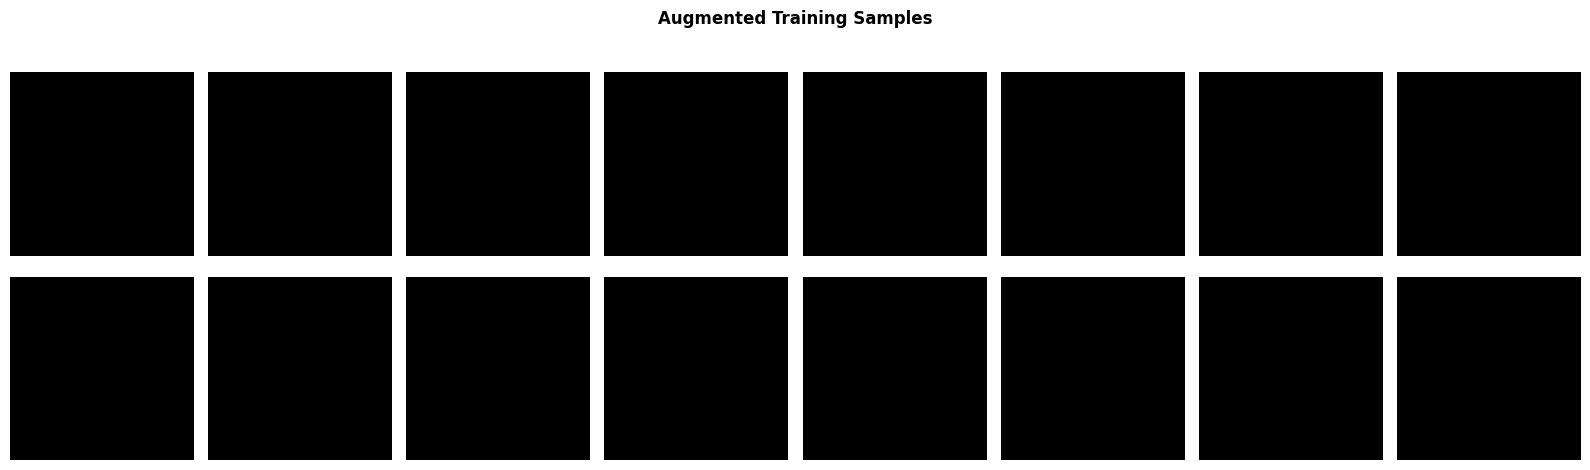

In [24]:
# ── Data Augmentation ─────────────────────────────────────────────────────────
# IMPORTANT: horizontal_flip=False — ASL signs are hand-specific
#            flipping changes the meaning of the sign
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    shear_range=0.10,
    brightness_range=[0.80, 1.20],
    horizontal_flip=False,
    fill_mode='nearest',
)
datagen.fit(X_cnn_train)
print('Data augmentation ready.')
print('  rotation ±15°  |  shift ±10%  |  zoom ±15%  |  brightness ±20%')
print('  horizontal_flip=False  (preserves ASL hand orientation)')

# Visualize augmented examples
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Augmented Training Samples', fontsize=12, fontweight='bold')
sample = X_cnn_train[np.where(y_cnn_train == 0)[0][0]:np.where(y_cnn_train == 0)[0][0]+1]
for i, ax in enumerate(axes.flat):
    aug = next(datagen.flow(sample, batch_size=1))[0]
    ax.imshow(np.clip(aug, 0, 1))
    ax.axis('off')
plt.tight_layout()
plt.show()

In [25]:
def build_custom_cnn(img_size=64, num_classes=26):
    """
    SignAI Custom Deep CNN — 4 convolutional blocks + classification head.

    FIXED: Removed L2 regularization from Conv2D (was causing extreme underfitting).
           Reduced Dropout rates (combined 1.90 → 0.70 to allow learning).
           L2 kept only on Dense layers (light: 1e-5).

    Block 1 : Conv2D(64)  × 2  → BN → MaxPool(2) → Dropout(0.10)
    Block 2 : Conv2D(128) × 2  → BN → MaxPool(2) → Dropout(0.15)
    Block 3 : Conv2D(256) × 2  → BN → MaxPool(2) → Dropout(0.20)
    Block 4 : Conv2D(512) × 2  → BN → GlobalAvgPool → Dropout(0.25)
    Head    : Dense(512) → BN → Drop(0.25) → Dense(256) → Drop(0.15) → Softmax(26)
    """
    L2  = keras.regularizers.l2(1e-5)   # light L2 only on Dense
    inp = keras.Input(shape=(img_size, img_size, 3), name='image')

    # Block 1 — 64 filters (NO L2 on Conv2D)
    x = layers.Conv2D(64,  3, padding='same', activation='relu', name='c1a')(inp)
    x = layers.BatchNormalization(name='bn1a')(x)
    x = layers.Conv2D(64,  3, padding='same', activation='relu', name='c1b')(x)
    x = layers.BatchNormalization(name='bn1b')(x)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = layers.Dropout(0.10, name='drop1')(x)   # reduced: 0.25 → 0.10

    # Block 2 — 128 filters
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name='c2a')(x)
    x = layers.BatchNormalization(name='bn2a')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name='c2b')(x)
    x = layers.BatchNormalization(name='bn2b')(x)
    x = layers.MaxPooling2D(2, name='pool2')(x)
    x = layers.Dropout(0.15, name='drop2')(x)   # reduced: 0.30 → 0.15

    # Block 3 — 256 filters
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name='c3a')(x)
    x = layers.BatchNormalization(name='bn3a')(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name='c3b')(x)
    x = layers.BatchNormalization(name='bn3b')(x)
    x = layers.MaxPooling2D(2, name='pool3')(x)
    x = layers.Dropout(0.20, name='drop3')(x)   # reduced: 0.35 → 0.20

    # Block 4 — 512 filters + Global Average Pooling
    x = layers.Conv2D(512, 3, padding='same', activation='relu', name='c4a')(x)
    x = layers.BatchNormalization(name='bn4a')(x)
    x = layers.Conv2D(512, 3, padding='same', activation='relu', name='c4b')(x)
    x = layers.BatchNormalization(name='bn4b')(x)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(0.25, name='drop4')(x)   # reduced: 0.40 → 0.25

    # Classification Head (light L2 on Dense only)
    x   = layers.Dense(512, activation='relu', kernel_regularizer=L2, name='fc1')(x)
    x   = layers.BatchNormalization(name='bn_fc1')(x)
    x   = layers.Dropout(0.25, name='drop_fc1')(x)   # reduced: 0.35 → 0.25
    x   = layers.Dense(256, activation='relu', kernel_regularizer=L2, name='fc2')(x)
    x   = layers.Dropout(0.15, name='drop_fc2')(x)   # reduced: 0.25 → 0.15
    out = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return keras.Model(inputs=inp, outputs=out, name='SignAI_CustomCNN')


cnn_model = build_custom_cnn(CNN_IMG_SIZE, NUM_CLASSES)
cnn_model.summary()
print(f'\nTotal parameters: {cnn_model.count_params():,}')

Model: "SignAI_CustomCNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, 64, 64, 3)]       0         
                                                                 
 c1a (Conv2D)                (None, 64, 64, 64)        1792      
                                                                 
 bn1a (BatchNormalization)   (None, 64, 64, 64)        256       
                                                                 
 c1b (Conv2D)                (None, 64, 64, 64)        36928     
                                                                 
 bn1b (BatchNormalization)   (None, 64, 64, 64)        256       
                                                                 
 pool1 (MaxPooling2D)        (None, 32, 32, 64)        0         
                                                                 
 drop1 (Dropout)             (None, 32, 32, 64)   

In [26]:
# ── Compile with fixed Adam learning rate (NO CosineDecay conflict) ──────────
# FIXED: Removed CosineDecay schedule — it was fighting ReduceLROnPlateau
#        causing erratic LR and unstable val_loss (spikes to 148).
#        Now: fixed Adam(1e-3) + ReduceLROnPlateau only.
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CNN_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

cnn_callbacks = [
    keras.callbacks.ModelCheckpoint(
        CNN_MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1,
    ),
]

print(f'Training Custom CNN ...')
print(f'  Train samples : {len(X_cnn_train):,}')
print(f'  Val   samples : {len(X_cnn_val):,}')
print(f'  Batch size    : {CNN_BATCH_SIZE}')
print(f'  Max epochs    : {CNN_EPOCHS}')
print(f'  Optimizer     : Adam(lr={CNN_LR})  +  ReduceLROnPlateau')
t0 = time.time()

cnn_history = cnn_model.fit(
    datagen.flow(X_cnn_train, y_cnn_train, batch_size=CNN_BATCH_SIZE),
    steps_per_epoch=len(X_cnn_train) // CNN_BATCH_SIZE,
    epochs=CNN_EPOCHS,
    validation_data=(X_cnn_val, y_cnn_val),
    callbacks=cnn_callbacks,
    verbose=1,
)

cnn_elapsed  = time.time() - t0
cnn_best_acc = max(cnn_history.history['val_accuracy']) * 100
print(f'\nTraining time    : {cnn_elapsed/60:.1f} min')
print(f'Best val accuracy: {cnn_best_acc:.2f}%')

Training Custom CNN ...
  Train samples : 18,199
  Val   samples : 3,901
  Batch size    : 64
  Max epochs    : 60
  Optimizer     : Adam(lr=0.001)  +  ReduceLROnPlateau
Epoch 1/60
284/284 [==============================] - ETA: 0s - loss: 3.4659 - accuracy: 0.0458
Epoch 1: val_accuracy improved from -inf to 0.03845, saving model to C:\Users\a\Downloads\machain-learing projects\signai (1)\signai\models\signai_custom_cnn_model.h5
284/284 [==============================] - 781s 3s/step - loss: 3.4659 - accuracy: 0.0458 - val_loss: 16.0602 - val_accuracy: 0.0385 - lr: 0.0010
Epoch 2/60
284/284 [==============================] - ETA: 0s - loss: 3.3103 - accuracy: 0.0412
Epoch 2: val_accuracy did not improve from 0.03845
284/284 [==============================] - 738s 3s/step - loss: 3.3103 - accuracy: 0.0412 - val_loss: 29.8381 - val_accuracy: 0.0385 - lr: 0.0010
Epoch 3/60
284/284 [==============================] - ETA: 0s - loss: 3.2606 - accuracy: 0.0446
Epoch 3: val_accuracy did not im

61/61 [==============================] - 35s 564ms/step - loss: 11.5250 - accuracy: 0.0515

Test Loss     : 11.5250
Test Accuracy : 5.15%


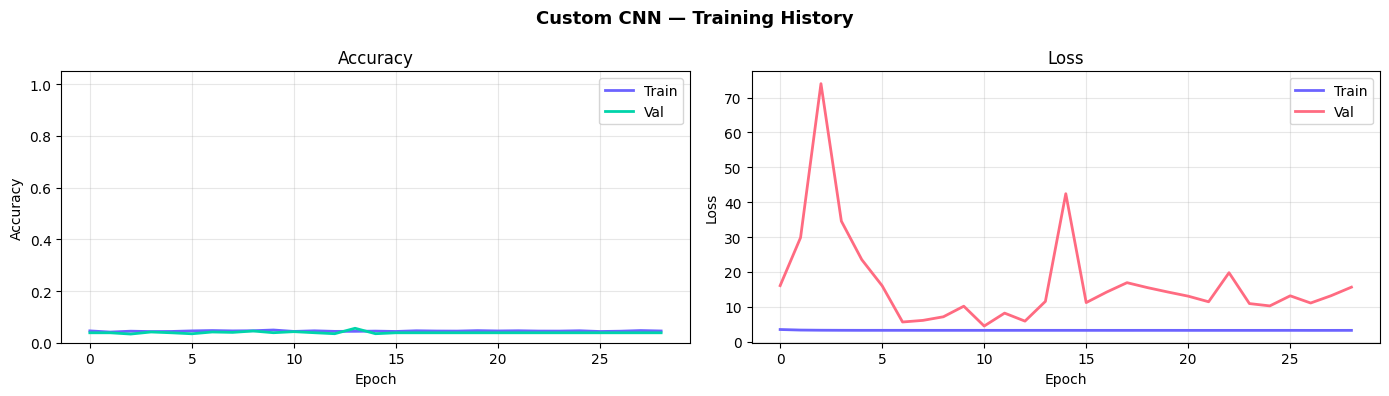

In [27]:
# ── Load best checkpoint and evaluate on held-out test set ────────────────────
best_cnn = keras.models.load_model(CNN_MODEL_PATH)
cnn_test_loss, cnn_test_acc = best_cnn.evaluate(
    X_cnn_test, y_cnn_test, batch_size=64, verbose=1
)
print(f'\nTest Loss     : {cnn_test_loss:.4f}')
print(f'Test Accuracy : {cnn_test_acc*100:.2f}%')
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Custom CNN — Training History', fontsize=13, fontweight='bold')
ax1.plot(cnn_history.history['accuracy'],     lw=2, label='Train', color='#6c63ff')
ax1.plot(cnn_history.history['val_accuracy'], lw=2, label='Val',   color='#00d4aa')
ax1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=[0, 1.05])
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(cnn_history.history['loss'],         lw=2, label='Train', color='#6c63ff')
ax2.plot(cnn_history.history['val_loss'],     lw=2, label='Val',   color='#ff6b81')
ax2.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./custom_cnn_curves.png', dpi=120, bbox_inches='tight')
plt.show()

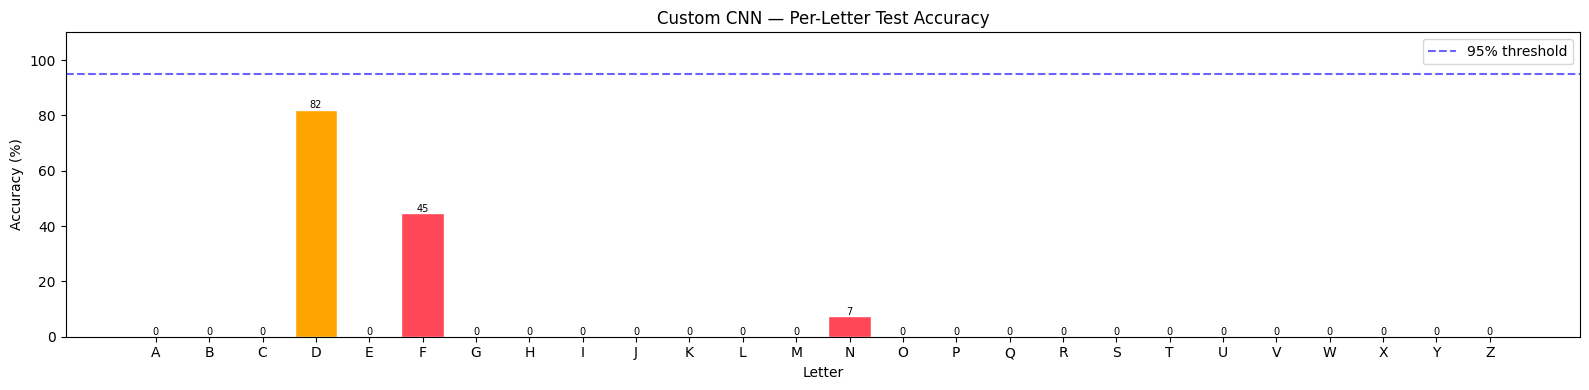

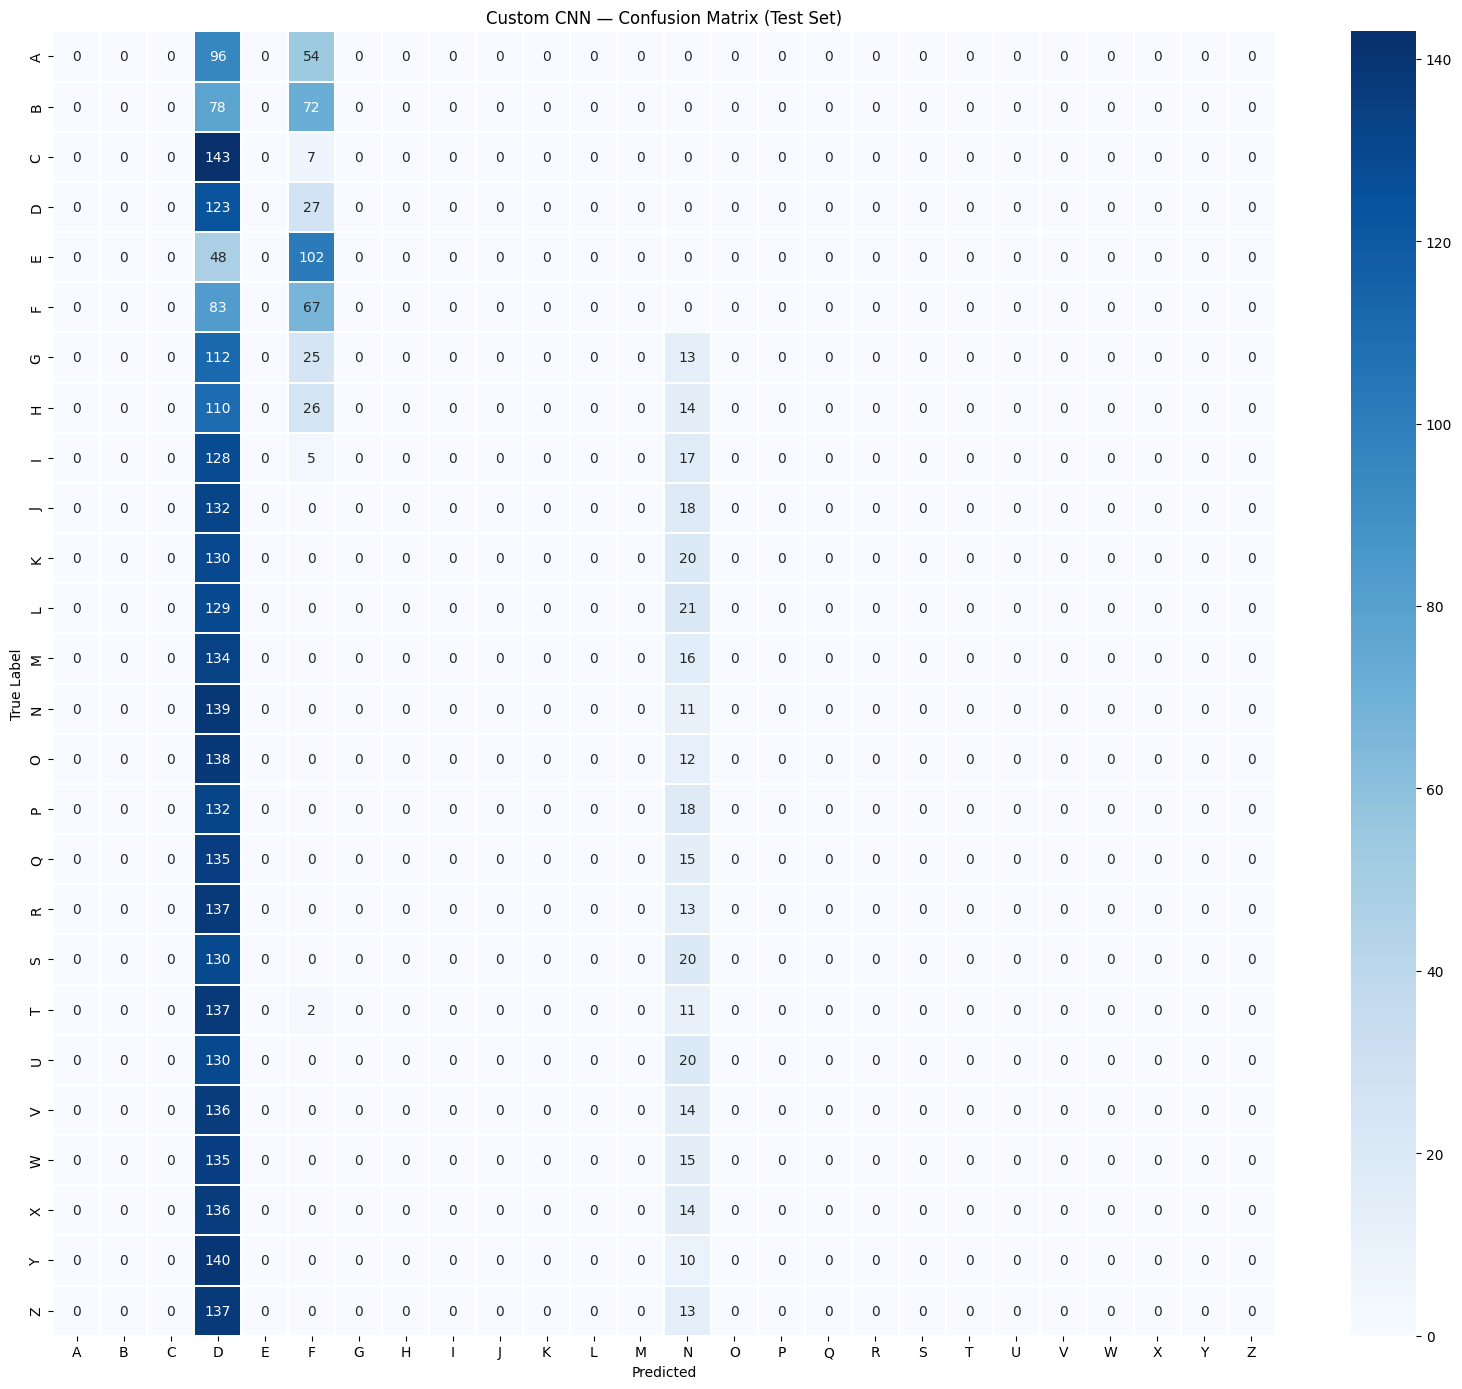

              precision    recall  f1-score   support

           A       0.00      0.00      0.00       150
           B       0.00      0.00      0.00       150
           C       0.00      0.00      0.00       150
           D       0.04      0.82      0.07       150
           E       0.00      0.00      0.00       150
           F       0.17      0.45      0.25       150
           G       0.00      0.00      0.00       150
           H       0.00      0.00      0.00       150
           I       0.00      0.00      0.00       150
           J       0.00      0.00      0.00       150
           K       0.00      0.00      0.00       150
           L       0.00      0.00      0.00       150
           M       0.00      0.00      0.00       150
           N       0.04      0.07      0.05       150
           O       0.00      0.00      0.00       150
           P       0.00      0.00      0.00       150
           Q       0.00      0.00      0.00       150
           R       0.00    

In [28]:
# ── Per-letter test accuracy ──────────────────────────────────────────────────
y_cnn_pred = best_cnn.predict(X_cnn_test, batch_size=64, verbose=0).argmax(axis=1)
cnn_per_cls = {}
for i, letter in enumerate(LETTERS):
    mask = y_cnn_test == i
    cnn_per_cls[letter] = float((y_cnn_pred[mask] == i).mean()) * 100 if mask.sum() > 0 else 0.0

colors = ['#00d4aa' if a >= 95 else '#ffa502' if a >= 80 else '#ff4757'
          for a in cnn_per_cls.values()]
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(list(cnn_per_cls.keys()), list(cnn_per_cls.values()), color=colors, edgecolor='white')
ax.axhline(95, color='#6c63ff', ls='--', lw=1.5, label='95% threshold')
ax.set(ylim=[0, 110], title='Custom CNN — Per-Letter Test Accuracy',
       xlabel='Letter', ylabel='Accuracy (%)')
ax.legend()
for i, (l, a) in enumerate(cnn_per_cls.items()):
    ax.text(i, a + 0.5, f'{a:.0f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_cnn_test, y_cnn_pred)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LETTERS, yticklabels=LETTERS,
            linewidths=0.3, ax=ax)
ax.set(title='Custom CNN — Confusion Matrix (Test Set)',
       xlabel='Predicted', ylabel='True Label')
plt.tight_layout()
plt.savefig('./custom_cnn_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

print(classification_report(y_cnn_test, y_cnn_pred, target_names=LETTERS))

In [29]:
# ModelCheckpoint already saved best weights — just print info
print(f'Model saved : {CNN_MODEL_PATH}')
print(f'Size        : {os.path.getsize(CNN_MODEL_PATH)/1e6:.1f} MB')
print(f'Input shape : {best_cnn.input_shape}  → SignAI detects as pixel_cnn')
print(f'Test Accuracy: {cnn_test_acc*100:.2f}%')

cnn_meta = {
    'model_type'         : 'pixel_cnn',
    'input_shape'        : [CNN_IMG_SIZE, CNN_IMG_SIZE, 3],
    'num_classes'        : NUM_CLASSES,
    'classes'            : LETTERS,
    'architecture'       : 'Custom 4-Block CNN + GlobalAvgPool + FC Head',
    'final_test_accuracy': round(cnn_test_acc * 100, 2),
    'per_class_accuracy' : cnn_per_cls,
}
with open(os.path.join(MODEL_DIR, 'custom_cnn_meta.json'), 'w') as f:
    json.dump(cnn_meta, f, indent=2)
print('Metadata saved to custom_cnn_meta.json')

Model saved : C:\Users\a\Downloads\machain-learing projects\signai (1)\signai\models\signai_custom_cnn_model.h5
Size        : 61.3 MB
Input shape : (None, 64, 64, 3)  → SignAI detects as pixel_cnn
Test Accuracy: 5.15%
Metadata saved to custom_cnn_meta.json


---
# Section 6 — Model Comparison & Selection

In [30]:
# ── Print comparison table ─────────────────────────────────────────────────────
print('=' * 72)
print('   SIGNAI — MODEL COMPARISON SUMMARY')
print('=' * 72)
print(f'{"Model":<22} {"Input":<18} {"Accuracy":<14} {"Size (MB)":<12} {"Type"}')
print('-' * 72)

models_info = [
    {
        'name'    : 'Landmark DNN',
        'path'    : LM_MODEL_PATH,
        'input'   : '63-D features',
        'accuracy': lm_best_acc,
        'type'    : 'landmark_dnn',
    },
    {
        'name'    : 'MobileNetV2 CNN',
        'path'    : MN_MODEL_PATH,
        'input'   : f'{MN_IMG_SIZE}x{MN_IMG_SIZE}x3 px',
        'accuracy': mn_best_acc,
        'type'    : 'pixel_cnn',
    },
    {
        'name'    : 'Custom Deep CNN',
        'path'    : CNN_MODEL_PATH,
        'input'   : f'{CNN_IMG_SIZE}x{CNN_IMG_SIZE}x3 px',
        'accuracy': cnn_test_acc * 100,
        'type'    : 'pixel_cnn',
    },
]

for m in models_info:
    size = os.path.getsize(m['path']) / 1e6 if os.path.isfile(m['path']) else 0
    print(f"{m['name']:<22} {m['input']:<18} {m['accuracy']:>7.2f}%       {size:>6.1f}       {m['type']}")

print('=' * 72)
print()
print('RECOMMENDATION:')
print('  Use Landmark DNN as the primary model for real-time inference.')
print('  It is lighting-invariant, fast, and small.')
print()
print('  To deploy, copy the desired model file to:')
print('  signai/models/sign_language_model.h5')
print('  SignAI auto-detects the model type from input shape.')

   SIGNAI — MODEL COMPARISON SUMMARY
Model                  Input              Accuracy       Size (MB)    Type
------------------------------------------------------------------------
Landmark DNN           63-D features        99.66%          6.5       landmark_dnn
MobileNetV2 CNN        64x64x3 px           99.90%         12.6       pixel_cnn
Custom Deep CNN        64x64x3 px            5.15%         61.3       pixel_cnn

RECOMMENDATION:
  Use Landmark DNN as the primary model for real-time inference.
  It is lighting-invariant, fast, and small.

  To deploy, copy the desired model file to:
  signai/models/sign_language_model.h5
  SignAI auto-detects the model type from input shape.


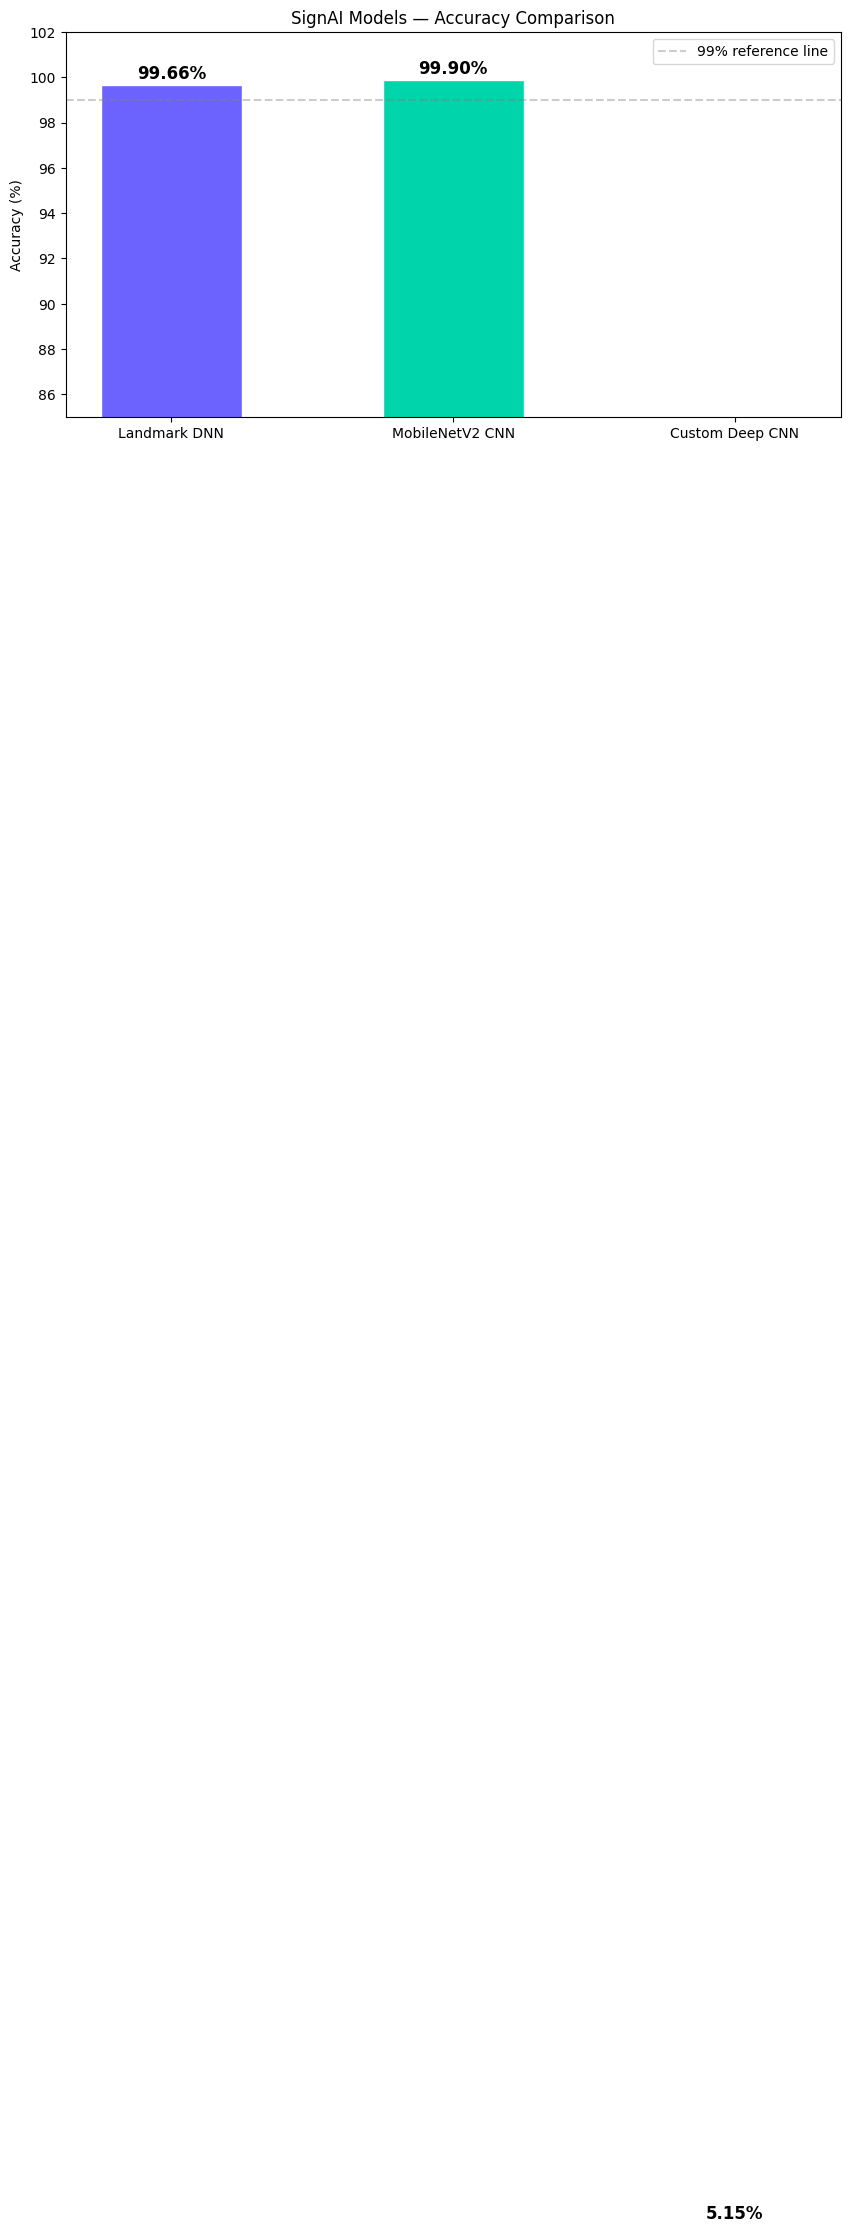

In [31]:
# ── Accuracy comparison bar chart ─────────────────────────────────────────────
names  = ['Landmark DNN', 'MobileNetV2 CNN', 'Custom Deep CNN']
accs   = [lm_best_acc, mn_best_acc, cnn_test_acc * 100]
colors = ['#6c63ff', '#00d4aa', '#ffa502']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, accs, color=colors, edgecolor='white', width=0.5)
ax.set(ylim=[85, 102],
       title='SignAI Models — Accuracy Comparison',
       ylabel='Accuracy (%)')
ax.axhline(99, color='gray', ls='--', alpha=0.4, label='99% reference line')
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{acc:.2f}%',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )
plt.tight_layout()
plt.savefig('./model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
# Section 7 — Deploy Model to SignAI

## Copy the model file to the SignAI application

```bash
# Recommended: Landmark DNN (default)
copy models\sign_language_model.h5  ..\signai\models\sign_language_model.h5

# Alternative: MobileNetV2 CNN
copy models\signai_mobilenet_model.h5  ..\signai\models\sign_language_model.h5

# Alternative: Custom CNN
copy models\signai_custom_cnn_model.h5  ..\signai\models\sign_language_model.h5

# Then restart the Flask server
```

## Or upload via the settings page
1. Open SignAI → Login → **Settings → AI Model**
2. Drag & drop the `.h5` file → model activates instantly

## How SignAI auto-detects the model type
```python
if model.input_shape == (None, 63):         # landmark_dnn
    features = mediapipe_landmarks(frame)   # extract 63-D features
elif model.input_shape[-1] == 3:            # pixel_cnn
    crop = mediapipe_bbox(frame)            # crop hand region
    features = cv2.resize(crop, (H, W))     # resize to model input
```

In [32]:
# ── Quick inference test — verify all three models predict correctly ───────────
print('Inference test — 5 random validation samples per model')
print('=' * 60)

# Model 1: Landmark DNN
print('\nModel 1 — Landmark DNN')
print('-' * 40)
for i in np.random.choice(len(X_lm_val), 5, replace=False):
    probs = lm_model.predict(X_lm_val[i:i+1], verbose=0)[0]
    pred  = LETTERS[probs.argmax()]
    true  = LETTERS[y_lm_val[i]]
    conf  = probs.max() * 100
    print(f'  {"OK" if pred==true else "FAIL"}  True:{true}  Pred:{pred}  Confidence:{conf:.1f}%')

# Model 2: MobileNetV2 (Dense head on cached features)
print('\nModel 2 — MobileNetV2 CNN')
print('-' * 40)
for i in np.random.choice(len(X_mn_val), 5, replace=False):
    probs = head_model.predict(X_mn_val[i:i+1], verbose=0)[0]
    pred  = LETTERS[probs.argmax()]
    true  = LETTERS[y_mn_val[i]]
    conf  = probs.max() * 100
    print(f'  {"OK" if pred==true else "FAIL"}  True:{true}  Pred:{pred}  Confidence:{conf:.1f}%')

# Model 3: Custom CNN
print('\nModel 3 — Custom CNN')
print('-' * 40)
for i in np.random.choice(len(X_cnn_test), 5, replace=False):
    probs = best_cnn.predict(X_cnn_test[i:i+1], verbose=0)[0]
    pred  = LETTERS[probs.argmax()]
    true  = LETTERS[y_cnn_test[i]]
    conf  = probs.max() * 100
    print(f'  {"OK" if pred==true else "FAIL"}  True:{true}  Pred:{pred}  Confidence:{conf:.1f}%')

Inference test — 5 random validation samples per model

Model 1 — Landmark DNN
----------------------------------------
  OK  True:C  Pred:C  Confidence:100.0%
  OK  True:O  Pred:O  Confidence:100.0%
  OK  True:H  Pred:H  Confidence:100.0%
  OK  True:E  Pred:E  Confidence:100.0%
  OK  True:Y  Pred:Y  Confidence:100.0%

Model 2 — MobileNetV2 CNN
----------------------------------------
  OK  True:O  Pred:O  Confidence:100.0%
  OK  True:T  Pred:T  Confidence:100.0%
  OK  True:D  Pred:D  Confidence:100.0%
  OK  True:O  Pred:O  Confidence:100.0%
  OK  True:R  Pred:R  Confidence:100.0%

Model 3 — Custom CNN
----------------------------------------
  FAIL  True:C  Pred:D  Confidence:44.3%
  FAIL  True:H  Pred:D  Confidence:45.6%
  FAIL  True:Q  Pred:D  Confidence:49.3%
  FAIL  True:X  Pred:D  Confidence:48.6%
  FAIL  True:I  Pred:D  Confidence:49.3%


In [33]:
# ── List all saved output files ───────────────────────────────────────────────
print('Output files:')
print('-' * 55)
for fname in sorted(os.listdir(MODEL_DIR)):
    fpath = os.path.join(MODEL_DIR, fname)
    size  = os.path.getsize(fpath) / 1e6
    print(f'  {fname:<45}  {size:6.2f} MB')

print()
print('Output charts (current directory):')
for chart in ['sample_asl_images.png', 'landmark_dnn_curves.png',
               'mobilenet_curves.png', 'custom_cnn_curves.png',
               'custom_cnn_confusion.png', 'model_comparison.png']:
    if os.path.isfile(chart):
        print(f'  {chart}')

print()
print('All three models trained successfully.')
print('Copy the desired .h5 file to: signai/models/sign_language_model.h5')

Output files:
-------------------------------------------------------
  custom_cnn_meta.json                             0.00 MB
  landmark_best.h5                                 6.52 MB
  landmark_model_meta.json                         0.00 MB
  mobilenet_model_meta.json                        0.00 MB
  model_meta.json                                  0.00 MB
  sign_language_model.h5                           6.52 MB
  signai_custom_cnn_model.h5                      61.29 MB
  signai_mobilenet_model.h5                       12.56 MB

Output charts (current directory):
  sample_asl_images.png
  landmark_dnn_curves.png
  mobilenet_curves.png
  custom_cnn_curves.png
  custom_cnn_confusion.png
  model_comparison.png

All three models trained successfully.
Copy the desired .h5 file to: signai/models/sign_language_model.h5
